## Import all the necessary config files

In [1]:
from config import *
from utils import *
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

## Run the coral model

In [2]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear)

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,2.600000,7.300000,8.000000,17.900000
1,1,2.546625,7.566936,8.114562,18.228124
2,2,1.016130,4.259081,5.688033,10.963244
3,3,1.068133,4.655089,5.961927,11.685150
4,4,1.140800,5.180109,6.269079,12.589988
5,5,1.214845,5.830597,6.677485,13.722928
6,6,1.287596,6.570327,7.075038,14.932961
7,7,1.363230,7.455881,7.507921,16.327032
8,8,0.877928,5.746110,5.950608,12.574647
9,9,0.796158,5.974514,5.852041,12.622713


## Plot the change in total coral cover over the years

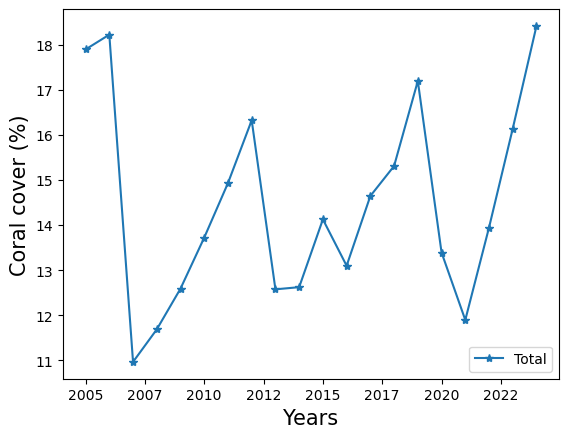

In [3]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [4]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,89.100000,43.300000,2.400000,4.000000,0.800000,36.100000,36.800000,4.000000,5.000000,17.900000,45.800000,107.000000
1,1,81.771876,43.527432,2.193677,4.217303,0.737840,32.996556,33.940662,3.074335,4.611503,18.228124,45.133333,106.888889
2,2,89.036756,43.148512,2.199523,6.631432,0.739807,33.692739,34.031112,7.118351,4.623792,10.963244,45.651596,99.763352
3,3,88.314850,43.530255,2.167034,7.524360,0.741467,33.195074,34.107477,5.945270,4.634168,11.685150,44.586863,99.802268
4,4,87.410012,43.548829,2.125329,8.206845,0.742870,32.556219,34.172039,4.963770,4.642940,12.589988,43.696036,99.834854
5,5,86.277072,43.187736,2.072498,8.693359,0.744060,31.746950,34.226738,4.143096,4.650372,13.722928,42.951454,99.862118
6,6,85.067039,42.622263,2.016237,9.033573,0.745068,30.885127,34.273106,3.457257,4.656672,14.932961,42.329690,99.884914
7,7,83.672968,41.766108,1.951450,9.224025,0.745924,29.892701,34.312487,2.884358,4.662023,16.327032,41.810825,99.903965
8,8,87.425353,44.460163,1.953541,10.792616,0.746723,31.014935,35.439458,2.811060,4.667019,12.574647,42.871588,99.906398
9,9,87.377287,44.746905,1.945134,11.181206,0.747410,30.914344,35.504966,2.412911,4.671315,12.622713,42.550025,99.919644


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

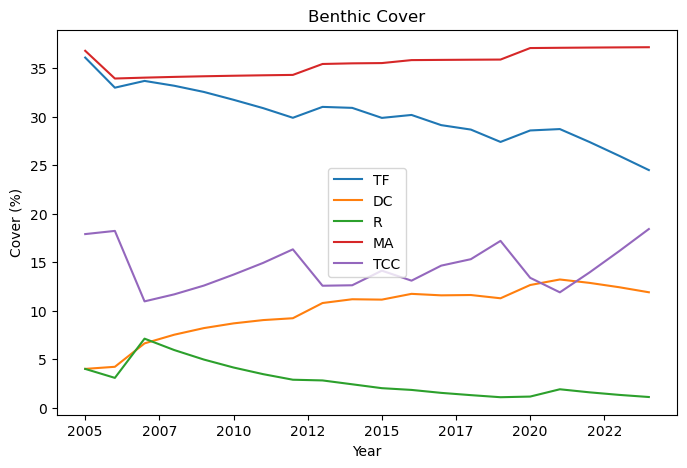

In [5]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [6]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots

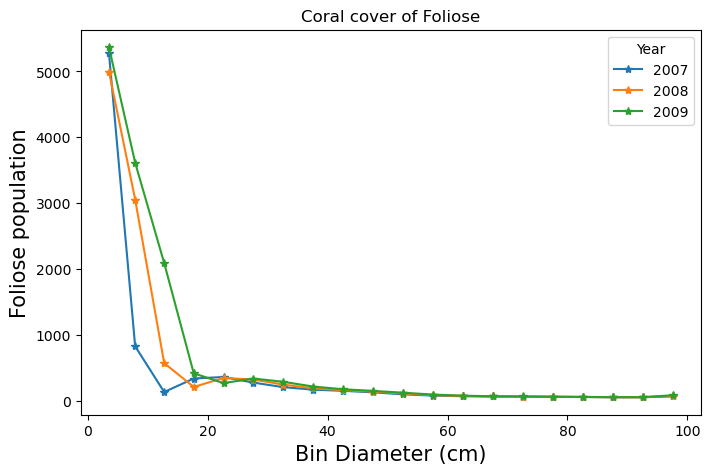

In [7]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2007, 2008, 2009

#Convert them to model years (indices) for the model)
model_years = tuple(year - year_start for year in Years)

#Plot coral population change by type
plot_coral_type_population_change('Foliose', False, *model_years)


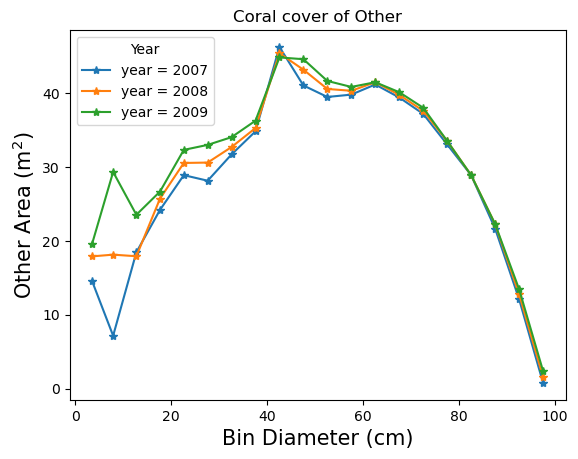

In [8]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
Years = 2007, 2008, 2009

#Convert them to model years (indices) for the model)
model_years = tuple(year - year_start for year in Years)

#Plot coral area change by type
plot_coral_type_areal_change('Other', False, *model_years)

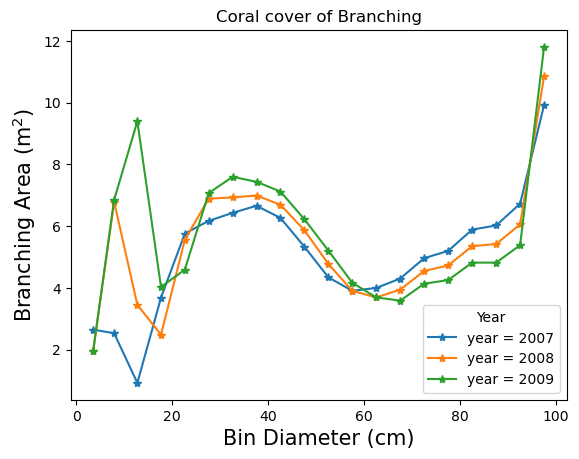

In [9]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
Years = 2007, 2008, 2009

#Convert them to model years (indices) for the model)
model_years = tuple(year - year_start for year in Years)

plot_coral_type_areal_change('Branching', False, *model_years)

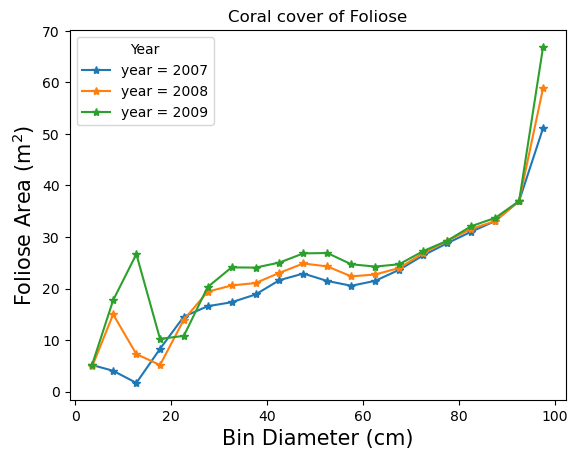

In [10]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
Years = 2007, 2008, 2009

#Convert them to model years (indices) for the model)
model_years = tuple(year - year_start for year in Years)

plot_coral_type_areal_change('Foliose',False, *model_years)

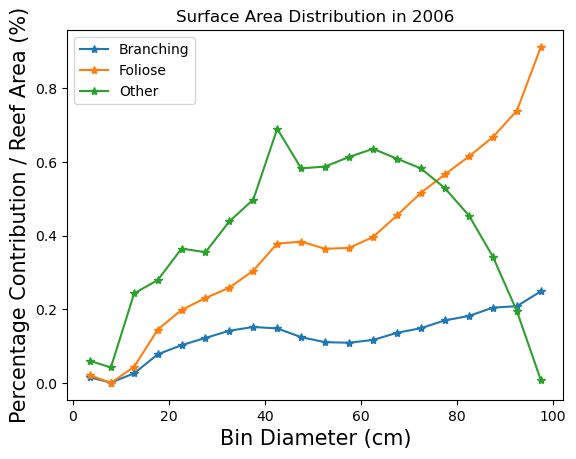

In [11]:
# Plot surface area distribution of different coral types in a given year.

Year = 2006

#Convert them to model years (indices) for the model)
model_year = Year - year_start

plot_surface_area_distribution(model_year)

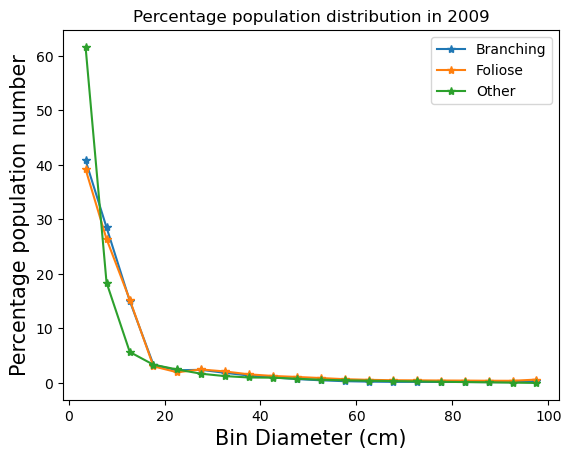

In [12]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2009

#Convert them to model years (indices) for the model)
model_year = Year - year_start

plot_population_distribution_in_percentage(model_year)

## Rugosity

In [13]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

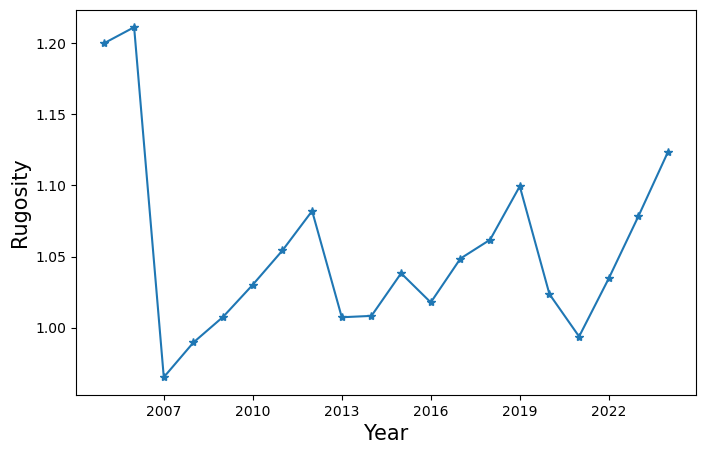

In [14]:
# This function plots the rugosity values over the years

plot_rugosity_year()

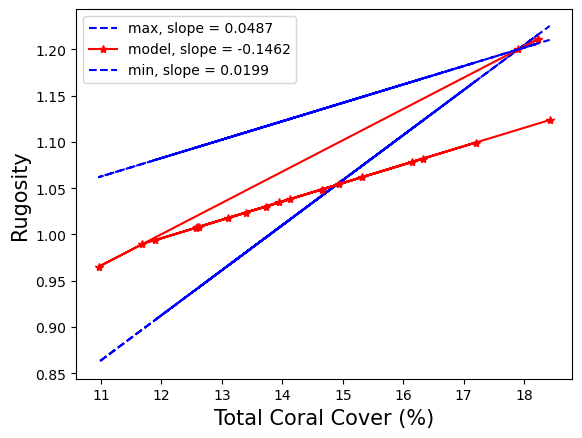

In [15]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

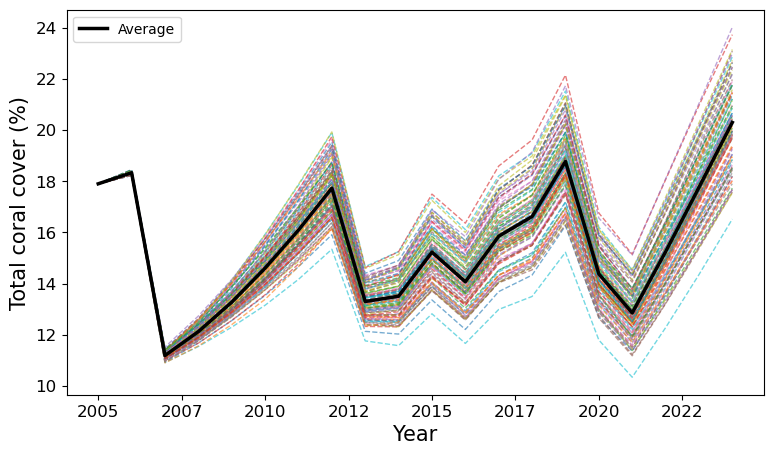

In [16]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [17]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100,averaged
0,0,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,...,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000
1,1,18.276494,18.274069,18.407106,18.332366,18.275679,18.252815,18.407391,18.309344,18.389248,...,18.301067,18.443077,18.311896,18.332768,18.326505,18.354867,18.351549,18.396061,18.365941,18.332315
2,2,11.133680,11.145913,11.368157,11.134054,11.056200,11.110852,11.287379,11.223695,11.239574,...,11.124355,11.406954,11.081822,11.241124,11.083555,11.273249,11.229435,11.242909,11.223608,11.190059
3,3,11.883205,12.030580,12.352555,11.982125,12.002113,11.915367,12.378266,12.143774,12.242422,...,11.876102,12.407040,11.901183,12.358024,11.914244,12.264616,12.179109,12.256928,12.145314,12.123763
4,4,12.843384,13.125346,13.579339,13.002842,13.285337,12.943724,13.682933,13.297498,13.458883,...,12.880041,13.588398,12.886526,13.692964,12.985963,13.530536,13.390765,13.432443,13.246070,13.274138
5,5,13.959126,14.355888,14.912846,14.227153,14.828821,14.141587,15.198541,14.631413,14.930756,...,13.965859,14.954528,13.974677,15.277551,14.212655,14.945221,14.748619,14.823756,14.588335,14.605348
6,6,15.167498,15.840631,16.402544,15.686438,16.515004,15.487589,16.909151,16.147292,16.535314,...,15.225305,16.534817,15.204450,17.021826,15.556747,16.454577,16.351743,16.451945,16.042633,16.092938
7,7,16.508076,17.476183,17.942730,17.242426,18.389978,17.011536,18.768220,17.758613,18.300418,...,16.581053,18.240751,16.591980,19.054958,17.061522,18.112810,17.980697,18.293735,17.633291,17.730454
8,8,12.580429,13.290184,13.468391,13.023767,13.768069,12.934938,13.930666,13.263843,13.685897,...,12.716598,13.648698,12.678192,14.134418,12.867492,13.573644,13.538949,13.690491,13.140035,13.301047
9,9,12.556308,13.524389,13.597127,13.200403,14.206361,13.086609,14.380110,13.482027,14.020653,...,12.669012,13.894832,12.719994,14.660812,12.936450,13.831323,13.782354,14.142812,13.315847,13.507720


## Predicting the effect of a cyclone on the whole colony mortality

In [18]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

,Branching,Foliose,Other
0,0.205730,0.203589,0.202156
1,0.196249,0.070711,0.058656
2,0.240649,0.099990,0.076879
3,0.202084,0.122713,0.091326
4,0.226584,0.119748,0.082336
5,0.244925,0.132718,0.090824
6,0.259044,0.142834,0.097509
7,0.270198,0.150907,0.102884
8,0.279211,0.157484,0.107291
9,0.286633,0.162936,0.110962


## The effect of bleaching on the partial colony mortality

In [19]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching

,Branching,Foliose,Other
0,0.017066,0.033362,0.033362
1,0.019749,0.038503,0.038503
2,0.022962,0.044632,0.044632
3,0.026827,0.051962,0.051962
4,0.031498,0.060755,0.060755
5,0.037167,0.071328,0.071328
6,0.044076,0.084067,0.084067
7,0.052528,0.099430,0.099430
8,0.062898,0.117954,0.117954
9,0.075651,0.140253,0.140253
